### 7 现代卷积神经网络
- AlexNet；
- 使用重复块的网络（VGG）利用许多重复的神经网路块；
- 网络中的网络（NiN）：重复使用卷积层喝1×1卷积层来构建深层网络；
- 含并行连接的网络（GoogLeNet）：使用并行连接的网络，通过不同窗口大小的卷积层和最大汇聚层来并行提取信息。
- 残差网络（ResNet）：通过残差块构建跨层的数据通道，是计算机视觉最流行的体系架构；
- 稠密连接网络（DenseNet）：计算成本高，效果好。

#### 7.1 深度卷积神经网络（AlexNet）
AlexNet由5卷积层、2全连接隐藏层、1全输出层组成，使用Sigmoid作为激活函数。

In [10]:
import torch
from torch import nn

net = nn.Sequential(
    # 使用11×11窗口捕获对象，步幅为4减少输出高度和宽度，输出通道远大于LeNet
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 减少卷积窗口，使用填充为2使得输入与输出的高和宽一致，增大输出通道数
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 使用三个连续的卷积层和较小的卷积窗口，除了最后的卷积层，输出通道进一步增加
    # 在前两个卷积层后，汇聚层不用于减少输入的高度和宽度
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    # 使用暂退层来缓解过拟合
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 10)
)

构造1×224×224的单通道数据，观察每一层输出的形状。

In [11]:
X = torch.randn(1, 1, 224, 224)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)

Conv2d output shape:	 torch.Size([1, 96, 54, 54])
ReLU output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Conv2d output shape:	 torch.Size([1, 256, 26, 26])
ReLU output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1,

loss 0.326, train acc 0.879, test acc 0.884
1238.8 examples/sec on cuda:0


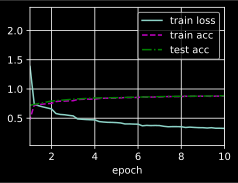

In [12]:
from d2l import torch as d2l
batch_size = 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
lr, num_epochs = 0.01, 10
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('cuda:0'))

loss 0.527, train acc 0.804, test acc 0.812
1409.6 examples/sec on cuda:0


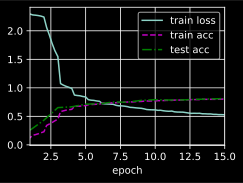

In [14]:
batch_size = 512
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
lr, num_epochs = 0.005, 15
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('cuda:0'))

loss 0.342, train acc 0.875, test acc 0.875
1347.3 examples/sec on cuda:0


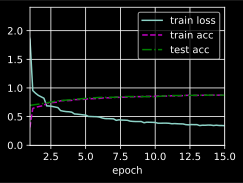

In [15]:
from d2l import torch as d2l
batch_size = 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
lr, num_epochs = 0.005, 15
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('cuda:0'))

#### 7.2 使用块的网络
VGG：Visual Geometry Group
##### 7.2.1 VGG块
卷积神经网络最基本组成序列：
- 带填充以保持分辨率的卷积层；
- 非线性激活函数，如ReLU；
- 汇聚层，如最大汇聚层。

在```vgg_block```函数实现一个VGG块。

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

def vgg_block(num_convs, in_channels, out_channels):
    """搭建一个VGG网络的模块块：多个3×3卷积+ReLU堆叠+一个2×2最大池化"""
    layers = []
    for _ in range(num_convs):      # 堆叠卷积层
        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        in_channels = out_channels
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))    # 池化层
    return nn.Sequential(*layers)

##### 7.2.2 池化网络
VGG可以分为两部风，第一部分主要由卷积层和汇聚层（池化层）组成，第二部分由全连接层组成。
- ```conv_arch```：指定每个VGG块中卷积层个数和输出通道数的超参数。
- 原始VGG网络包含5个卷积块，前2个块各包含一个卷积层，后3个块个包含两个卷积层。第一个块有64个输出通道，后续每个块输出通道数翻倍，直至512个。
- 该网络包含8个卷积层和3个全连接层，亦成为VGG-11。

In [2]:
conv_arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))

In [3]:
def vgg(conv_arch):
    conv_blks = []
    in_channels = 1
    # 卷积层部分
    for (num_convs, out_channels) in conv_arch:
        conv_blks.append(vgg_block(num_convs, in_channels, out_channels))
        in_channels = out_channels
    return nn.Sequential(
        *conv_blks, nn.Flatten(),
        # 全连接层
        nn.Linear(out_channels * 7 * 7, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 10)
    )
net = vgg(conv_arch)

In [4]:
X = torch.randn(size=(1, 1, 224, 224))
for blk in net:
    X = blk(X)
    print(blk.__class__.__name__, 'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 112, 112])
Sequential output shape:	 torch.Size([1, 128, 56, 56])
Sequential output shape:	 torch.Size([1, 256, 28, 28])
Sequential output shape:	 torch.Size([1, 512, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


##### 7.2.3 训练模型

In [5]:
ratio = 4
small_conv_arch = [(pair[0], pair[1] // ratio) for pair in conv_arch]
net = vgg(small_conv_arch)

loss 0.176, train acc 0.936, test acc 0.922
990.6 examples/sec on cuda:0


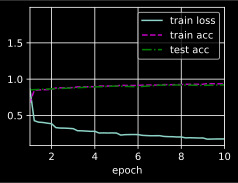

In [6]:
lr, num_epochs, batch_size = 0.05, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('cuda:0'))